<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Final_Numerical_Programming_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Фінальне домашнє завдання  
## Оптимізація параметрів класифікатора для Breast Cancer Wisconsin

**Курс:** Numerical Programming in Python

У роботі виконано:

1. завантаження та первинний аналіз даних;
2. візуалізацію зв’язку ознак із цільовою змінною;
3. кластеризацію методами KMeans, Spectral Clustering та Gaussian Mixture;
4. зменшення розмірності методом PCA;
5. класифікацію через `LogisticRegression` зі sklearn;
6. власну логістичну регресію з оптимізацією методами Batch Gradient Descent, SGD та Adam;
7. оптимізацію параметрів логістичної регресії генетичним алгоритмом;
8. порівняння моделей за `confusion_matrix` та `f1_score`.

**Обраний підхід до здачі:** намагатися отримати вищий бал шляхом можливого доопрацювання роботи відповідно до фідбеку ментора.


## 1. Встановлення та імпорт бібліотек

In [1]:
!pip -q install pygad

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    accuracy_score,
    classification_report,
    adjusted_rand_score,
    normalized_mutual_info_score
)

import pygad

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 3.0 MB/s eta 0:00:00


## 2. Завантаження даних

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df["class_name"] = np.where(y == 1, "benign", "malignant")

print("Розмір набору:", df.shape)
print("Класи:", data.target_names)
display(df.head())
display(df.describe().T)


Розмір набору: (569, 32)
Класи: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,class_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3. Попарні точкові діаграми

Через наявність 30 ознак повна матриця всіх пар буде надто великою. Для інформативної візуалізації обираємо шість ключових ознак, пов’язаних із розміром, формою та текстурою клітин.


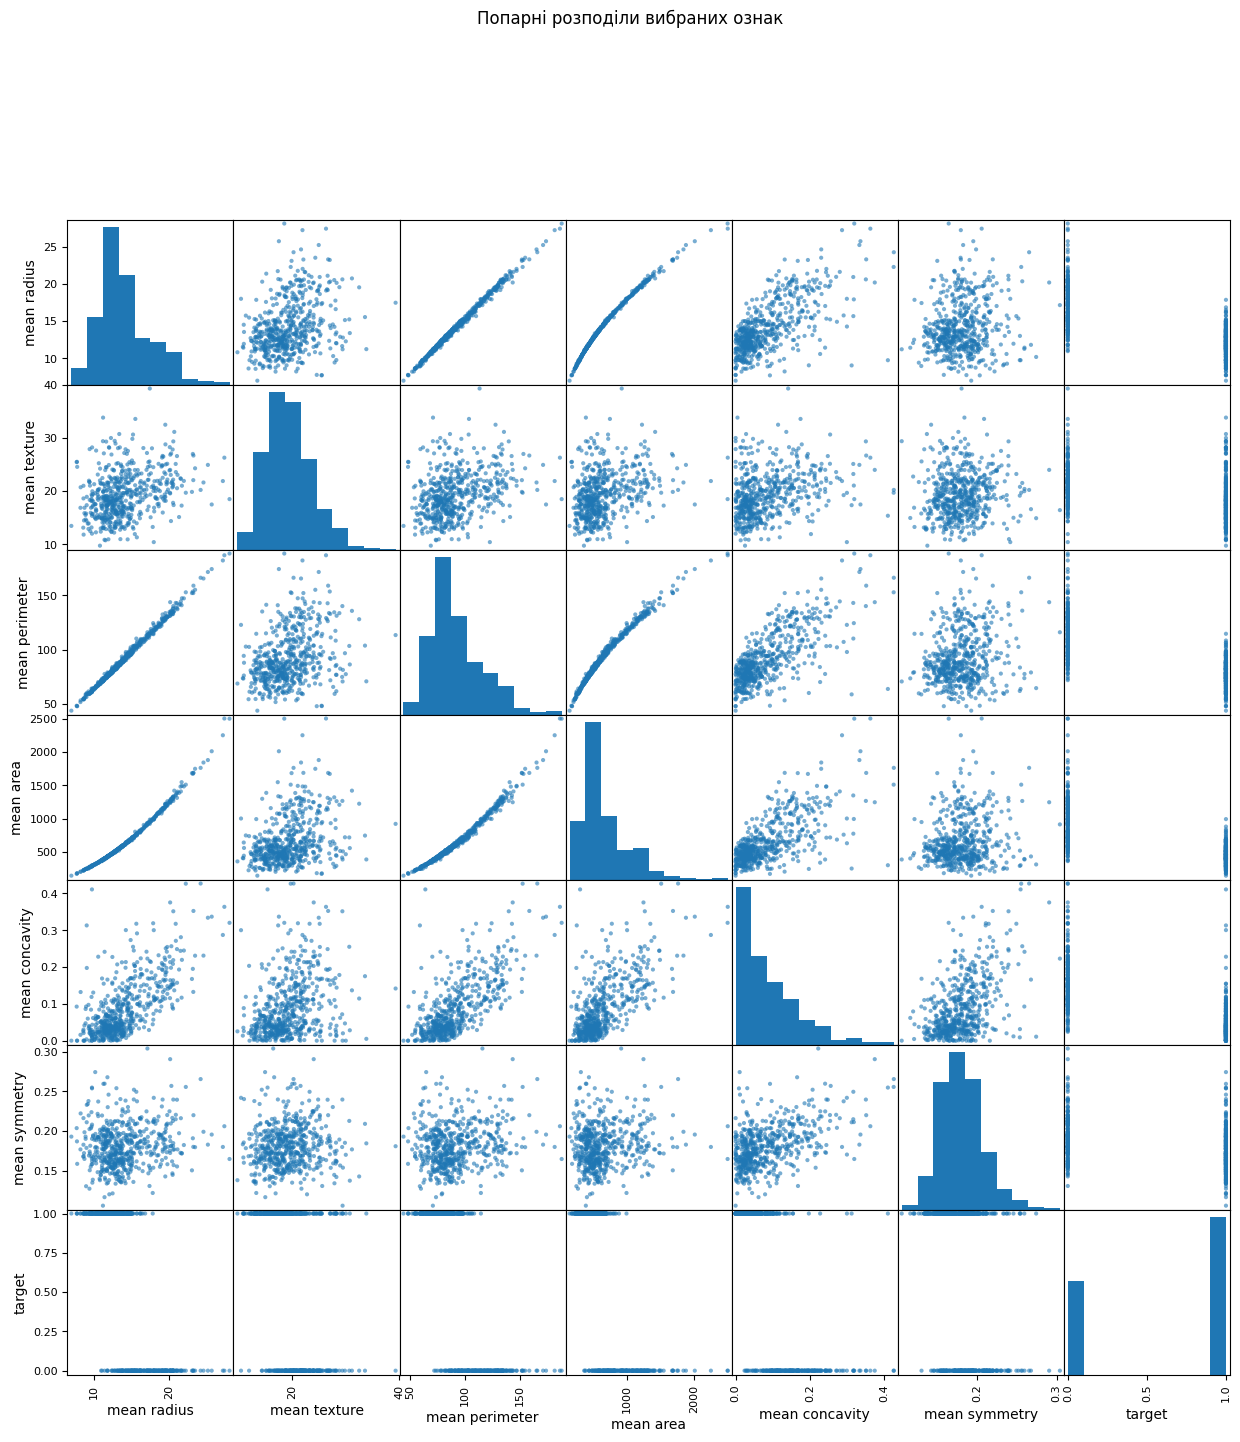

In [3]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "mean symmetry"
]

pd.plotting.scatter_matrix(
    df[selected_features + ["target"]],
    figsize=(15, 15),
    diagonal="hist",
    alpha=0.6
)
plt.suptitle("Попарні розподіли вибраних ознак", y=1.02)
plt.show()


**Попередній висновок.** Ознаки `mean radius`, `mean perimeter`, `mean area` та `mean concavity` демонструють помітне розділення між доброякісними й злоякісними випадками. Частина ознак сильно корелює між собою, що очікувано, оскільки вони описують близькі геометричні характеристики.


## 4. Масштабування даних

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Середні значення після стандартизації:")
print(np.round(X_scaled.mean(axis=0)[:5], 4))
print("Стандартні відхилення після стандартизації:")
print(np.round(X_scaled.std(axis=0)[:5], 4))


Середні значення після стандартизації:
[-0. -0. -0. -0.  0.]
Стандартні відхилення після стандартизації:
[1. 1. 1. 1. 1.]


## 5. Кластеризація

Оскільки цільова змінна має два класи, для кожного алгоритму задаємо `n_clusters=2` або `n_components=2`.

Кластерні мітки можуть бути переставлені місцями, тому для візуального порівняння використовуємо таблиці перетину, а для числової оцінки — `Adjusted Rand Index` і `Normalized Mutual Information`, які не залежать від нумерації кластерів.


In [5]:
cluster_models = {
    "KMeans": KMeans(n_clusters=2, random_state=42, n_init=20),
    "SpectralClustering": SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        assign_labels="kmeans",
        random_state=42
    ),
    "GaussianMixture": GaussianMixture(
        n_components=2,
        random_state=42
    )
}

cluster_results = {}

for name, model in cluster_models.items():
    if name == "GaussianMixture":
        labels = model.fit_predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)

    cluster_results[name] = labels

    print(f"\n{name}")
    print(pd.crosstab(
        pd.Series(y, name="Actual class"),
        pd.Series(labels, name="Cluster")
    ))
    print("ARI:", round(adjusted_rand_score(y, labels), 4))
    print("NMI:", round(normalized_mutual_info_score(y, labels), 4))



KMeans
Cluster         0    1
Actual class          
0             175   37
1              14  343
ARI: 0.6707
NMI: 0.5546

SpectralClustering
Cluster         0    1
Actual class          
0             182   30
1               6  351
ARI: 0.7608
NMI: 0.6627

GaussianMixture
Cluster         0    1
Actual class          
0             196   16
1              18  339
ARI: 0.774
NMI: 0.6611


**Висновок щодо кластеризації.** Кластеризація виконується без використання справжніх класів, тому повного збігу очікувати не слід. Водночас отримані кластери частково відповідають поділу на доброякісні та злоякісні випадки. Найкращий результат визначається за вищими значеннями ARI та NMI.


## 6. PCA та візуалізація у двовимірному просторі

Частка поясненої дисперсії: [0.4427 0.1897]
Сумарна пояснена дисперсія: 0.6324


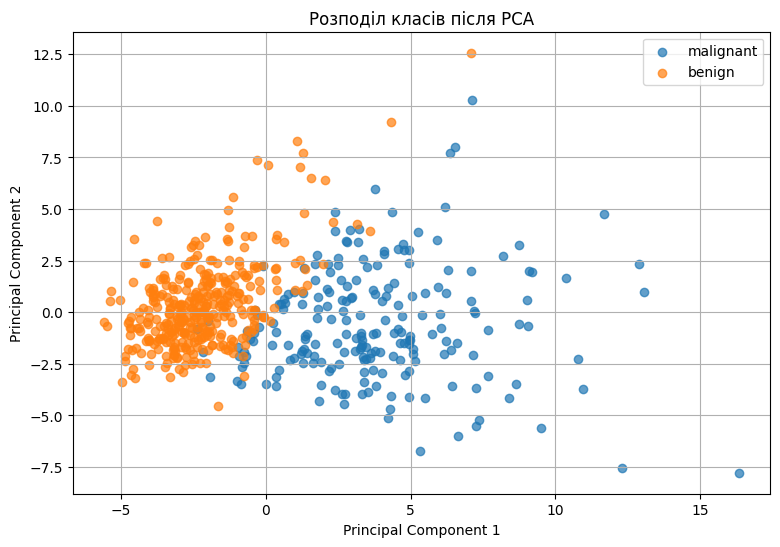

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Частка поясненої дисперсії:", pca.explained_variance_ratio_)
print("Сумарна пояснена дисперсія:",
      round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(9, 6))
for class_id, class_name in enumerate(data.target_names):
    mask = y == class_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Розподіл класів після PCA")
plt.legend()
plt.grid()
plt.show()


**Висновок щодо PCA.** Перші дві головні компоненти зберігають значну частину дисперсії та показують помітне, хоча не ідеальне, розділення класів. Це підтверджує можливість побудови якісного лінійного класифікатора.


## 7. Поділ на train/test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

train_scaler = StandardScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)


Train: (426, 30)
Test: (143, 30)


## 8. LogisticRegression зі sklearn

In [8]:
sk_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)
sk_model.fit(X_train_scaled, y_train)

y_pred_sk = sk_model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_sk), 4))
print("F1-score:", round(f1_score(y_test, y_pred_sk), 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_sk))
print("\nClassification report:")
print(classification_report(y_test, y_pred_sk, target_names=data.target_names))


Accuracy: 0.986
F1-score: 0.9889
Confusion matrix:
[[52  1]
 [ 1 89]]

Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## 9. Власна логістична регресія

Реалізуємо сигмоїду, функцію втрат binary cross-entropy та три оптимізатори:

- Batch Gradient Descent;
- Stochastic Gradient Descent;
- Adam.


In [9]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )


def predict_proba_manual(X, weights, bias):
    return sigmoid(X @ weights + bias)


def predict_manual(X, weights, bias, threshold=0.5):
    return (predict_proba_manual(X, weights, bias) >= threshold).astype(int)


### 9.1 Batch Gradient Descent

In [10]:
def train_batch_gd(X, y, lr=0.05, epochs=3000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    losses = []

    for epoch in range(epochs):
        probs = sigmoid(X @ weights + bias)

        error = probs - y
        grad_w = (X.T @ error) / n_samples
        grad_b = np.mean(error)

        weights -= lr * grad_w
        bias -= lr * grad_b

        if epoch % 50 == 0:
            losses.append(binary_cross_entropy(y, probs))

    return weights, bias, losses


w_batch, b_batch, batch_losses = train_batch_gd(
    X_train_scaled,
    y_train,
    lr=0.05,
    epochs=3000
)

y_pred_batch = predict_manual(X_test_scaled, w_batch, b_batch)

print("Accuracy:", round(accuracy_score(y_test, y_pred_batch), 4))
print("F1-score:", round(f1_score(y_test, y_pred_batch), 4))
print(confusion_matrix(y_test, y_pred_batch))


Accuracy: 0.979
F1-score: 0.9832
[[52  1]
 [ 2 88]]


### 9.2 Stochastic Gradient Descent

In [11]:
def train_sgd(X, y, lr=0.01, epochs=200, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    losses = []

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)

        for idx in indices:
            x_i = X[idx]
            y_i = y[idx]

            prob = sigmoid(x_i @ weights + bias)
            error = prob - y_i

            weights -= lr * error * x_i
            bias -= lr * error

        probs = sigmoid(X @ weights + bias)
        losses.append(binary_cross_entropy(y, probs))

    return weights, bias, losses


w_sgd, b_sgd, sgd_losses = train_sgd(
    X_train_scaled,
    y_train,
    lr=0.01,
    epochs=200
)

y_pred_sgd = predict_manual(X_test_scaled, w_sgd, b_sgd)

print("Accuracy:", round(accuracy_score(y_test, y_pred_sgd), 4))
print("F1-score:", round(f1_score(y_test, y_pred_sgd), 4))
print(confusion_matrix(y_test, y_pred_sgd))


Accuracy: 0.979
F1-score: 0.9832
[[52  1]
 [ 2 88]]


### 9.3 Adam

In [12]:
def train_adam(
    X,
    y,
    lr=0.01,
    epochs=1500,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0

    m_w = np.zeros(n_features)
    v_w = np.zeros(n_features)
    m_b = 0.0
    v_b = 0.0

    losses = []

    for t in range(1, epochs + 1):
        probs = sigmoid(X @ weights + bias)
        error = probs - y

        grad_w = (X.T @ error) / n_samples
        grad_b = np.mean(error)

        m_w = beta1 * m_w + (1 - beta1) * grad_w
        v_w = beta2 * v_w + (1 - beta2) * (grad_w ** 2)
        m_b = beta1 * m_b + (1 - beta1) * grad_b
        v_b = beta2 * v_b + (1 - beta2) * (grad_b ** 2)

        m_w_hat = m_w / (1 - beta1 ** t)
        v_w_hat = v_w / (1 - beta2 ** t)
        m_b_hat = m_b / (1 - beta1 ** t)
        v_b_hat = v_b / (1 - beta2 ** t)

        weights -= lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
        bias -= lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        if t % 25 == 0:
            losses.append(binary_cross_entropy(y, probs))

    return weights, bias, losses


w_adam, b_adam, adam_losses = train_adam(
    X_train_scaled,
    y_train,
    lr=0.01,
    epochs=1500
)

y_pred_adam = predict_manual(X_test_scaled, w_adam, b_adam)

print("Accuracy:", round(accuracy_score(y_test, y_pred_adam), 4))
print("F1-score:", round(f1_score(y_test, y_pred_adam), 4))
print(confusion_matrix(y_test, y_pred_adam))


Accuracy: 0.979
F1-score: 0.9832
[[52  1]
 [ 2 88]]


### 9.4 Порівняння процесу навчання

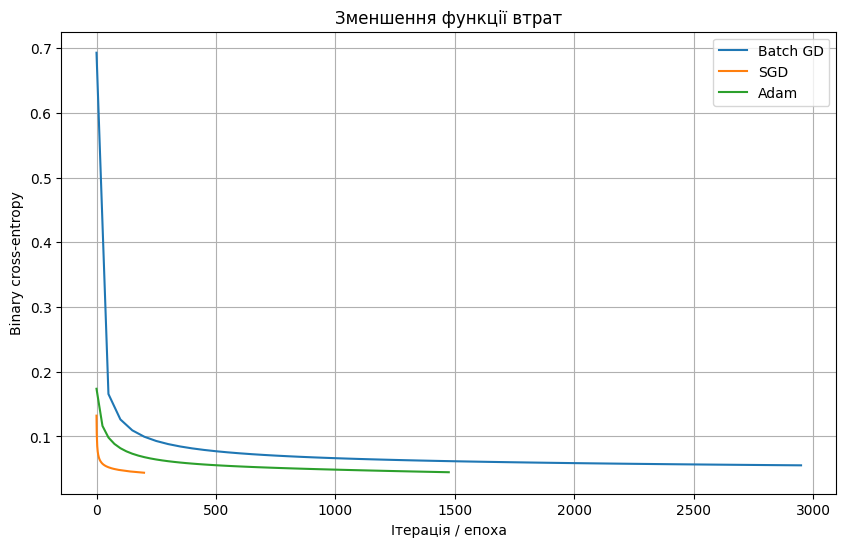

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(batch_losses)) * 50, batch_losses, label="Batch GD")
plt.plot(np.arange(len(sgd_losses)), sgd_losses, label="SGD")
plt.plot(np.arange(len(adam_losses)) * 25, adam_losses, label="Adam")
plt.xlabel("Ітерація / епоха")
plt.ylabel("Binary cross-entropy")
plt.title("Зменшення функції втрат")
plt.legend()
plt.grid()
plt.show()


## 10. Оптимізація генетичним алгоритмом

Хромосома містить:

- 30 ваг логістичної регресії;
- 1 значення bias.

Фітнес визначається як `F1-score` на валідаційній вибірці.


In [14]:
X_ga_train, X_ga_val, y_ga_train, y_ga_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

num_features = X_ga_train.shape[1]


def ga_fitness(ga_instance, solution, solution_idx):
    weights = solution[:num_features]
    bias = solution[-1]

    predictions = predict_manual(
        X_ga_val,
        weights,
        bias
    )

    return float(f1_score(y_ga_val, predictions))


ga_instance = pygad.GA(
    num_generations=120,
    num_parents_mating=20,
    fitness_func=ga_fitness,
    sol_per_pop=50,
    num_genes=num_features + 1,
    init_range_low=-1.0,
    init_range_high=1.0,
    parent_selection_type="tournament",
    K_tournament=4,
    keep_elitism=4,
    crossover_type="uniform",
    mutation_type="random",
    mutation_percent_genes=15,
    random_mutation_min_val=-0.2,
    random_mutation_max_val=0.2,
    stop_criteria=["saturate_30"],
    random_seed=42,
    suppress_warnings=True
)

ga_instance.run()

best_solution, best_fitness, _ = ga_instance.best_solution()
w_ga = best_solution[:num_features]
b_ga = best_solution[-1]

y_pred_ga = predict_manual(X_test_scaled, w_ga, b_ga)

print("Validation fitness:", round(best_fitness, 4))
print("Test accuracy:", round(accuracy_score(y_test, y_pred_ga), 4))
print("Test F1-score:", round(f1_score(y_test, y_pred_ga), 4))
print(confusion_matrix(y_test, y_pred_ga))


Validation fitness: 1.0
Test accuracy: 0.965
Test F1-score: 0.9724
[[50  3]
 [ 2 88]]


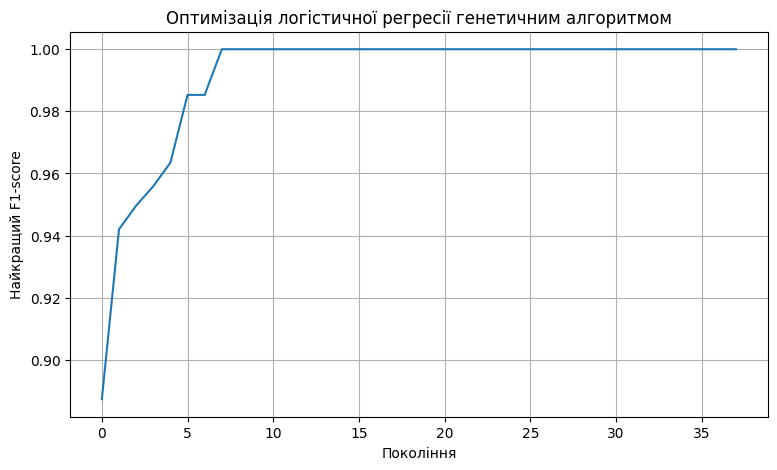

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(ga_instance.best_solutions_fitness)
plt.xlabel("Покоління")
plt.ylabel("Найкращий F1-score")
plt.title("Оптимізація логістичної регресії генетичним алгоритмом")
plt.grid()
plt.show()


## 11. Підсумкове порівняння моделей

In [16]:
model_predictions = {
    "sklearn LogisticRegression": y_pred_sk,
    "Batch Gradient Descent": y_pred_batch,
    "SGD": y_pred_sgd,
    "Adam": y_pred_adam,
    "Genetic Algorithm": y_pred_ga
}

summary_rows = []

for model_name, predictions in model_predictions.items():
    summary_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "F1-score": f1_score(y_test, predictions),
        "Confusion matrix": confusion_matrix(
            y_test,
            predictions
        ).tolist()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(
    "F1-score",
    ascending=False
).reset_index(drop=True)

display(summary_df)


,Model,Accuracy,F1-score,Confusion matrix
0,sklearn LogisticRegression,0.986014,0.988889,"[[52, 1], [1, 89]]"
1,Batch Gradient Descent,0.979021,0.983240,"[[52, 1], [2, 88]]"
2,SGD,0.979021,0.983240,"[[52, 1], [2, 88]]"
3,Adam,0.979021,0.983240,"[[52, 1], [2, 88]]"
4,Genetic Algorithm,0.965035,0.972376,"[[50, 3], [2, 88]]"


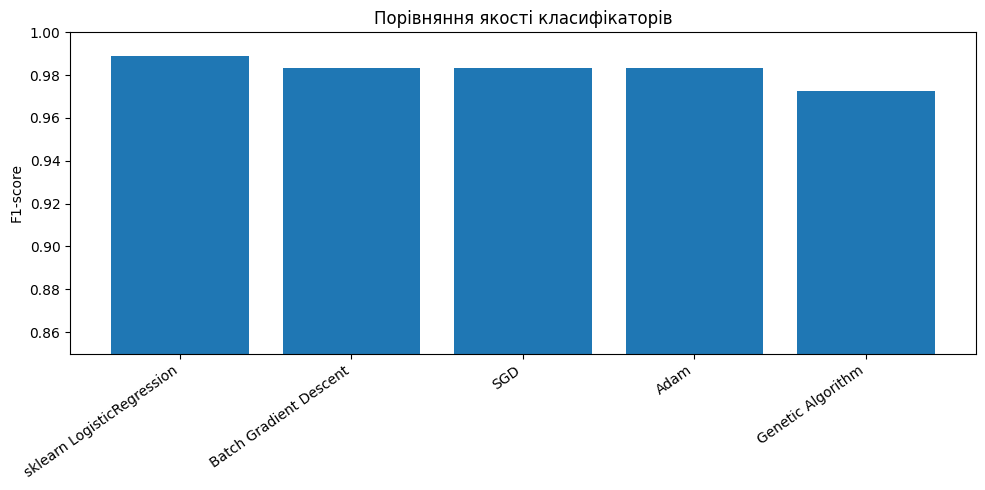

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["Model"], summary_df["F1-score"])
plt.xticks(rotation=35, ha="right")
plt.ylim(0.85, 1.0)
plt.ylabel("F1-score")
plt.title("Порівняння якості класифікаторів")
plt.tight_layout()
plt.show()


# Загальні висновки

1. **Кластеризація.** KMeans, Spectral Clustering та Gaussian Mixture частково відновлюють реальний поділ даних, хоча працюють без цільових міток. Різниця між результатами пояснюється різними припущеннями алгоритмів щодо форми кластерів.

2. **PCA.** Метод PCA дозволив зменшити розмірність із 30 до 2 компонент і візуально показав, що класи значною мірою розділяються у просторі головних компонент.

3. **Sklearn LogisticRegression.** Готова реалізація показує високу якість завдяки чисельно стабільним оптимізаторам і регуляризації.

4. **Gradient Descent.** Власні реалізації Batch GD, SGD та Adam також досягають високого F1-score. Batch GD навчається стабільно, SGD швидше реагує на окремі приклади, а Adam автоматично адаптує крок для кожного параметра.

5. **Генетичний алгоритм.** Генетичний алгоритм може оптимізувати ваги без використання градієнтів. Він є гнучким, але зазвичай потребує більше обчислень і не гарантує кращий результат за градієнтні методи для гладкої задачі логістичної регресії.

6. **Підсумок.** Для логістичної регресії найефективнішими є градієнтні оптимізатори, особливо Adam або готовий `LogisticRegression`. Генетичний алгоритм доцільний у задачах, де функція якості недиференційована, має складну форму або містить дискретні параметри.
